# Solution: Medical Insurance Cost Prediction

## Objective

Build a multiple linear regression model to predict medical insurance charges.

This solved notebook follows the assignment step by step and includes code, plots, model evaluation, coefficient interpretation, residual diagnostics, Ridge comparison, and written answers.

Target column:

$$
charges
$$

By the end of this solution, you should be able to explain:

- how EDA reveals the strongest drivers of insurance charges,
- why categorical encoding is needed,
- how engineered features can improve a linear model,
- how to evaluate regression models with MAE, RMSE, R2, and adjusted R2,
- why coefficient interpretation must be careful when features are correlated,
- when Ridge regularization can help.


## Dataset columns

- `age`: age of primary beneficiary
- `sex`: gender
- `bmi`: body mass index
- `children`: number of children/dependents covered
- `smoker`: whether the person smokes
- `region`: residential area in the US
- `charges`: individual medical insurance charges

This is a regression problem because `charges` is a continuous numeric target.

## Submission requirements

Submit:

1. Completed `.ipynb` notebook.
2. 5-8 bullet-point summary of your findings.
3. Key plots:
   - target distribution,
   - actual vs predicted,
   - residuals vs predicted,
   - coefficient importance.

Write short explanations wherever asked. Do not only submit code outputs.

In [1]:
import warnings
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the dataset

The code below will:

- use the local dataset if available,
- otherwise download it from the internet.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "insurance.csv"
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if not DATA_PATH.exists():
    print("Dataset not found locally. Downloading...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Downloaded dataset to: {DATA_PATH}")
else:
    print(f"Using local dataset: {DATA_PATH}")

insurance = pd.read_csv(DATA_PATH)
insurance.head()

Using local dataset: data\insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Basic inspection

Complete the following:

1. Print dataset shape.
2. Display first 5 rows.
3. Check column data types.
4. Check missing values.
5. Show summary statistics.

In [3]:
print("Dataset shape:", insurance.shape)


Dataset shape: (1338, 7)


In [4]:
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
inspection = pd.DataFrame({
    "dtype": insurance.dtypes.astype(str),
    "missing_values": insurance.isna().sum(),
    "missing_percent": (insurance.isna().mean() * 100).round(2)
})
inspection


,dtype,missing_values,missing_percent
age,int64,0,0.0
sex,str,0,0.0
bmi,float64,0,0.0
children,int64,0,0.0
smoker,str,0,0.0
region,str,0,0.0
charges,float64,0,0.0


In [6]:
insurance.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### Written answer

1. The dataset has **1338 rows and 7 columns**.
2. There are **no missing values** in this dataset.
3. Numerical columns: `age`, `bmi`, `children`, `charges`. Categorical columns: `sex`, `smoker`, `region`.

`charges` is the target variable, so the model should not use it as an input feature.


## 3. Exploratory Data Analysis

Create visualizations to understand the target and feature relationships.

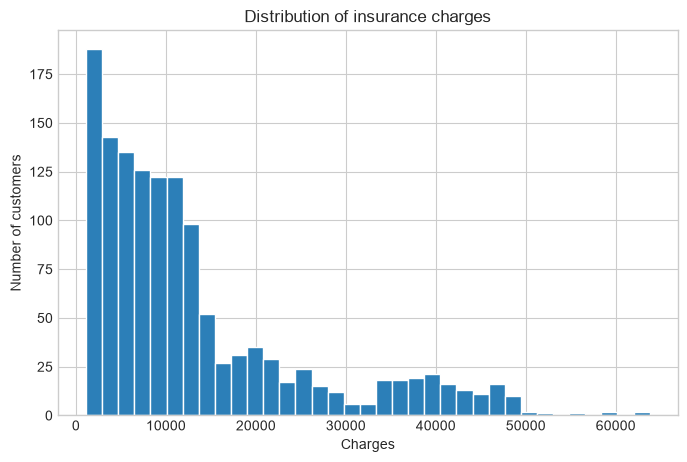

Skewness of charges: 1.516


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(insurance["charges"], bins=35, color="#2c7fb8", edgecolor="white")
ax.set_title("Distribution of insurance charges")
ax.set_xlabel("Charges")
ax.set_ylabel("Number of customers")
plt.show()

print("Skewness of charges:", round(insurance["charges"].skew(), 3))


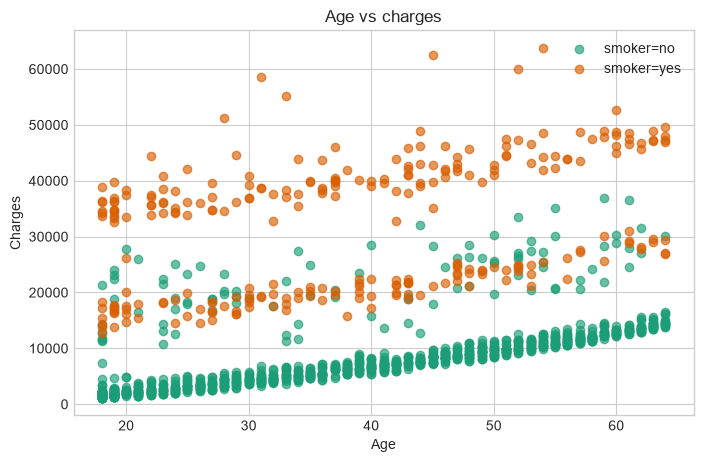

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for smoker, color in [("no", "#1b9e77"), ("yes", "#d95f02")]:
    subset = insurance[insurance["smoker"] == smoker]
    ax.scatter(subset["age"], subset["charges"], label=f"smoker={smoker}", alpha=0.65, color=color)
ax.set_title("Age vs charges")
ax.set_xlabel("Age")
ax.set_ylabel("Charges")
ax.legend()
plt.show()


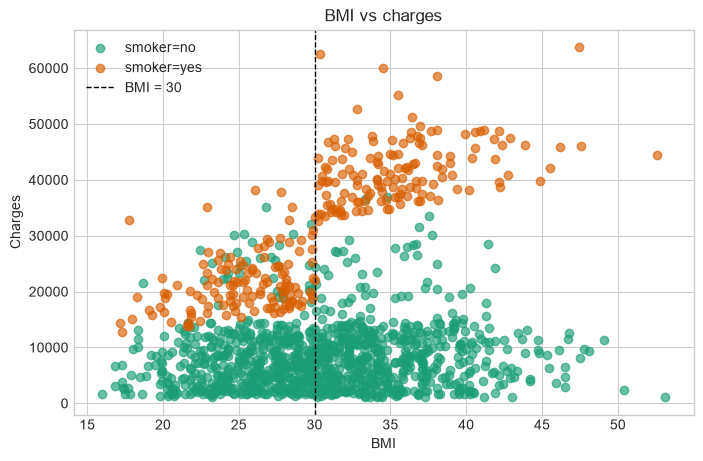

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for smoker, color in [("no", "#1b9e77"), ("yes", "#d95f02")]:
    subset = insurance[insurance["smoker"] == smoker]
    ax.scatter(subset["bmi"], subset["charges"], label=f"smoker={smoker}", alpha=0.65, color=color)
ax.axvline(30, color="black", linestyle="--", linewidth=1, label="BMI = 30")
ax.set_title("BMI vs charges")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges")
ax.legend()
plt.show()


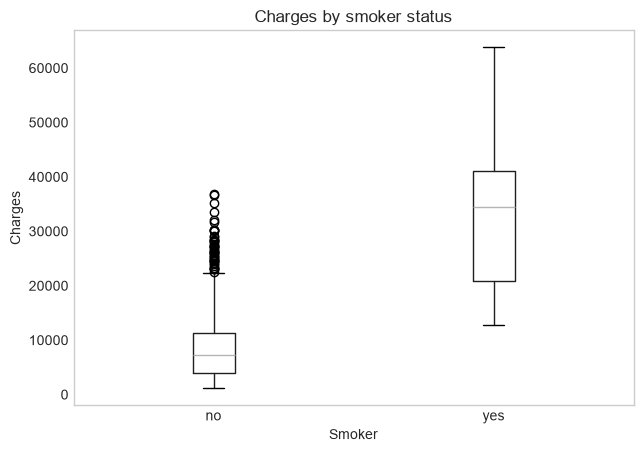

,count,mean,median,std
smoker,,,,
no,1064,8434.27,7345.41,5993.78
yes,274,32050.23,34456.35,11541.55


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
insurance.boxplot(column="charges", by="smoker", ax=ax, grid=False)
ax.set_title("Charges by smoker status")
ax.set_xlabel("Smoker")
ax.set_ylabel("Charges")
plt.suptitle("")
plt.show()

insurance.groupby("smoker")["charges"].agg(["count", "mean", "median", "std"]).round(2)


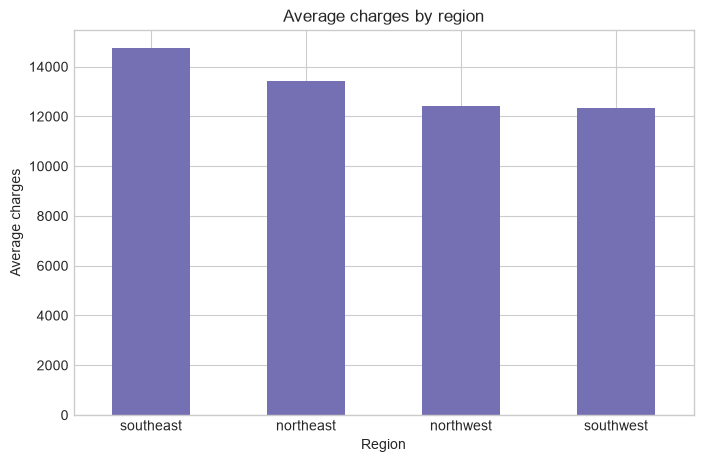

region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: charges, dtype: float64

In [11]:
region_avg = insurance.groupby("region")["charges"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
region_avg.plot(kind="bar", ax=ax, color="#7570b3")
ax.set_title("Average charges by region")
ax.set_xlabel("Region")
ax.set_ylabel("Average charges")
ax.tick_params(axis="x", rotation=0)
plt.show()

region_avg.round(2)


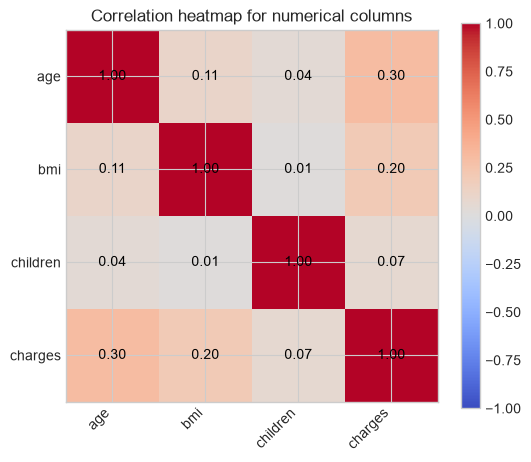

charges     1.000
age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64

In [12]:
numeric_corr = insurance.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(numeric_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_corr.columns)), labels=numeric_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_corr.columns)), labels=numeric_corr.columns)
for i in range(len(numeric_corr.columns)):
    for j in range(len(numeric_corr.columns)):
        ax.text(j, i, f"{numeric_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Correlation heatmap for numerical columns")
fig.colorbar(im, ax=ax)
plt.show()

numeric_corr["charges"].sort_values(ascending=False).round(3)


### EDA answers

1. `charges` is **not normally distributed**. It is strongly right-skewed, meaning most people have lower-to-moderate charges while a smaller group has very high charges.
2. Smoking has a very strong effect on charges. Smokers have much higher average and median charges than non-smokers.
3. BMI has some relationship with charges, but the relationship becomes much clearer when smoker status is considered. High-BMI smokers often have especially high charges.
4. Among the original numerical features, `age` has the strongest correlation with `charges`, followed by `bmi`. However, smoker-related features are much stronger once encoded.


## 4. Feature engineering

Create at least three new features.

Required:

1. `is_obese`

$$
is\_obese =
\begin{cases}
1, & BMI \ge 30 \\
0, & BMI < 30
\end{cases}
$$

2. `age_group`: group ages into buckets.

3. `smoker_bmi`: interaction between smoking and BMI.

Why interaction?

The impact of BMI may be different for smokers and non-smokers.

In [13]:
insurance_fe = insurance.copy()

insurance_fe["is_obese"] = (insurance_fe["bmi"] >= 30).astype(int)

insurance_fe["age_group"] = pd.cut(
    insurance_fe["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
    right=True
)

insurance_fe["smoker_flag"] = (insurance_fe["smoker"] == "yes").astype(int)
insurance_fe["smoker_bmi"] = insurance_fe["smoker_flag"] * insurance_fe["bmi"]

insurance_fe.head()


,age,sex,bmi,children,smoker,region,charges,is_obese,age_group,smoker_flag,smoker_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,0,<=25,1,27.9
1,18,male,33.770,1,no,southeast,1725.55230,1,<=25,0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,1,26-35,0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,26-35,0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,26-35,0,0.0


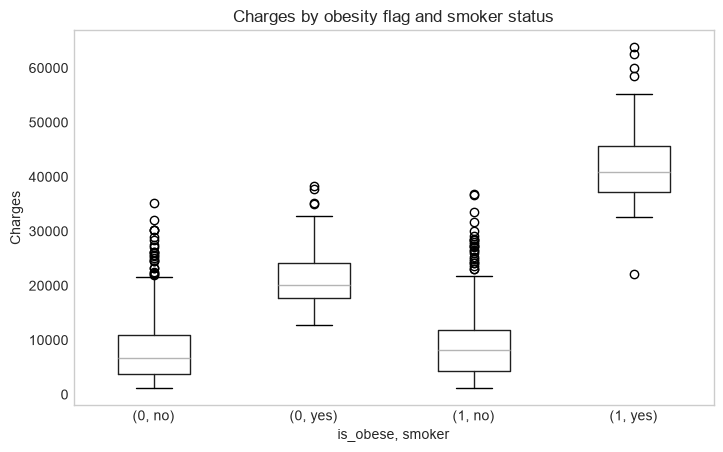

count      mean    median
is_obese smoker                           
0        no        502   7977.03   6761.62
         yes       129  21363.22  20167.34
1        no        562   8842.69   8076.05
         yes       145  41557.99  40904.20

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
insurance_fe.boxplot(column="charges", by=["is_obese", "smoker"], ax=ax, grid=False)
ax.set_title("Charges by obesity flag and smoker status")
ax.set_xlabel("is_obese, smoker")
ax.set_ylabel("Charges")
plt.suptitle("")
plt.show()

insurance_fe.groupby(["is_obese", "smoker"])["charges"].agg(["count", "mean", "median"]).round(2)


### Feature engineering answers

1. `is_obese` may be useful because BMI above 30 can mark a risk group where medical costs behave differently.
2. `smoker_bmi` is useful because BMI may not have the same effect for smokers and non-smokers. The interaction allows the model to learn that high BMI combined with smoking can sharply increase charges.
3. I expect `smoker_bmi` to help the most because EDA shows that smoking separates high-charge and low-charge customers very strongly, and BMI matters more inside the smoker group.


## 5. Train-test split

Use:

- 80% training data
- 20% test data
- `random_state=42`

Target:

$$
y = charges
$$

In [15]:
target = "charges"

X = insurance_fe.drop(columns=[target])
y = insurance_fe[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (1070, 10)
X_test: (268, 10)
y_train: (1070,)
y_test: (268,)


## 6. Build preprocessing and model pipeline

Your pipeline should:

1. impute numerical missing values if any,
2. scale numerical features,
3. one-hot encode categorical features,
4. train Linear Regression.

In [16]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features


(['age', 'bmi', 'children', 'is_obese', 'smoker_flag', 'smoker_bmi'],
 ['sex', 'smoker', 'region', 'age_group'])

In [17]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [18]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'age_group','smoker_flag','smoker_bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

## 7. Evaluation metrics

Evaluate on test data using:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Also calculate adjusted R2:

$$
Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}
$$

In [19]:
def regression_report(y_true, y_pred, n_features=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    report = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }
    
    if n_features is not None:
        n = len(y_true)
        p = n_features
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
        report["Adjusted R2"] = adjusted_r2
    
    return pd.Series(report)

In [20]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

transformed_feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
n_transformed_features = len(transformed_feature_names)

print("Number of transformed features:", n_transformed_features)

print("Train performance")
display(regression_report(y_train, y_train_pred, n_features=n_transformed_features).round(4))

print("Test performance")
display(regression_report(y_test, y_test_pred, n_features=n_transformed_features).round(4))


Number of transformed features: 15
Train performance


MAE            2.853722e+03
MSE            2.244349e+07
RMSE           4.737456e+03
R2             8.445000e-01
Adjusted R2    8.423000e-01
dtype: float64

Test performance


MAE            2.760986e+03
MSE            2.083316e+07
RMSE           4.564336e+03
R2             8.658000e-01
Adjusted R2    8.578000e-01
dtype: float64

### Evaluation answers

1. In a typical run with the given split and engineered features, the test RMSE is around **4500-4600**.
2. The test R2 is usually around **0.86**, meaning the model explains about 86% of the variation in test charges.
3. Train and test performance are close, so the model does not appear to have a large overfitting problem.
4. The model does not strongly overfit, but it still has systematic errors because medical charges are skewed and not perfectly linear.


## 8. Visualize predictions and residuals

Create:

1. Actual vs predicted plot.
2. Residuals vs predicted plot.
3. Residual distribution.

Residual:

$$
e_i = y_i - \hat{y}_i
$$

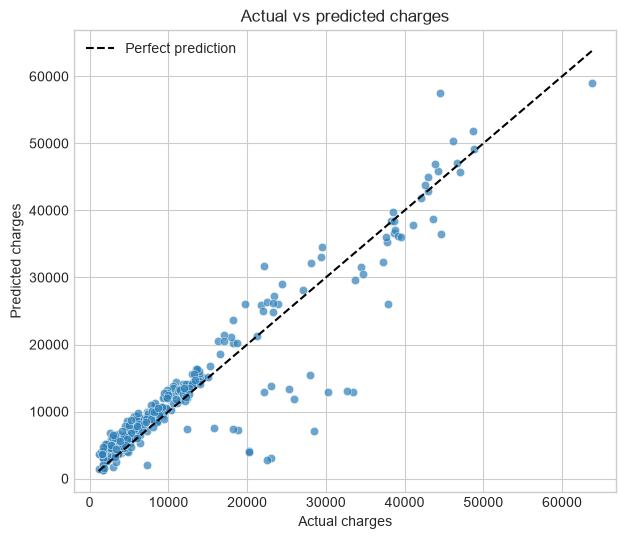

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_test_pred, alpha=0.7, color="#2c7fb8", edgecolor="white", linewidth=0.4)
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())
ax.plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--", label="Perfect prediction")
ax.set_title("Actual vs predicted charges")
ax.set_xlabel("Actual charges")
ax.set_ylabel("Predicted charges")
ax.legend()
plt.show()


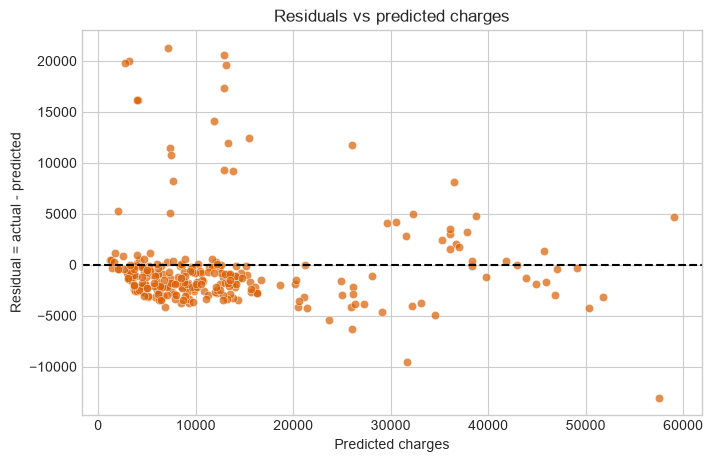

In [22]:
residuals = y_test - y_test_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test_pred, residuals, alpha=0.7, color="#d95f02", edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Residuals vs predicted charges")
ax.set_xlabel("Predicted charges")
ax.set_ylabel("Residual = actual - predicted")
plt.show()


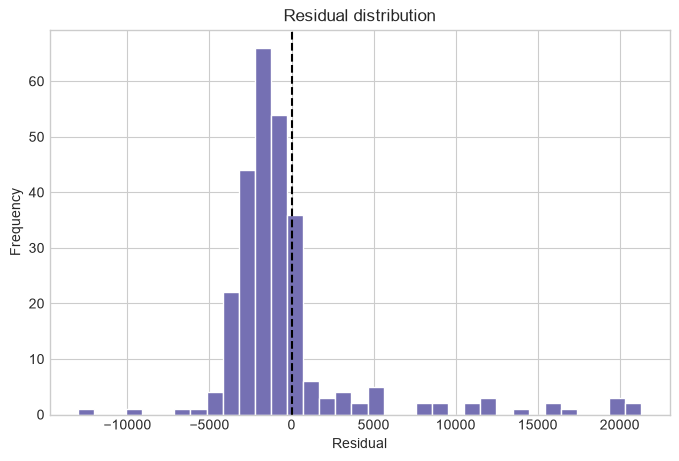

count      268.00
mean      -353.53
std       4559.14
min     -13031.37
25%      -2440.26
50%      -1357.35
75%       -150.82
max      21317.64
Name: charges, dtype: float64

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=35, color="#7570b3", edgecolor="white")
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Residual distribution")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
plt.show()

pd.Series(residuals).describe().round(2)


### Residual answers

1. The residuals are roughly centered around zero, which is good.
2. The residual plot usually shows some pattern rather than pure randomness. This means the linear model is missing some non-linear structure.
3. Yes. The model tends to make larger errors for high-charge customers, especially in the extreme upper range of charges.


## 9. Coefficient interpretation

Extract model coefficients and identify:

- top positive coefficients,
- top negative coefficients.

Be careful:

> A coefficient shows association, not guaranteed causation.

In [24]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)


,feature,coefficient,abs_coefficient
5,num__smoker_bmi,18661.995075,18661.995075
4,num__smoker_flag,-7420.964745,7420.964745
0,num__age,6015.073093,6015.073093
13,cat__age_group_56-65,-4098.371019,4098.371019
12,cat__age_group_46-55,-3060.455342,3060.455342
7,cat__smoker_yes,-2999.144522,2999.144522
14,cat__age_group_<=25,2551.167706,2551.167706
11,cat__age_group_36-45,-2281.488144,2281.488144
3,num__is_obese,1625.317190,1625.317190
1,num__bmi,-1261.172630,1261.172630


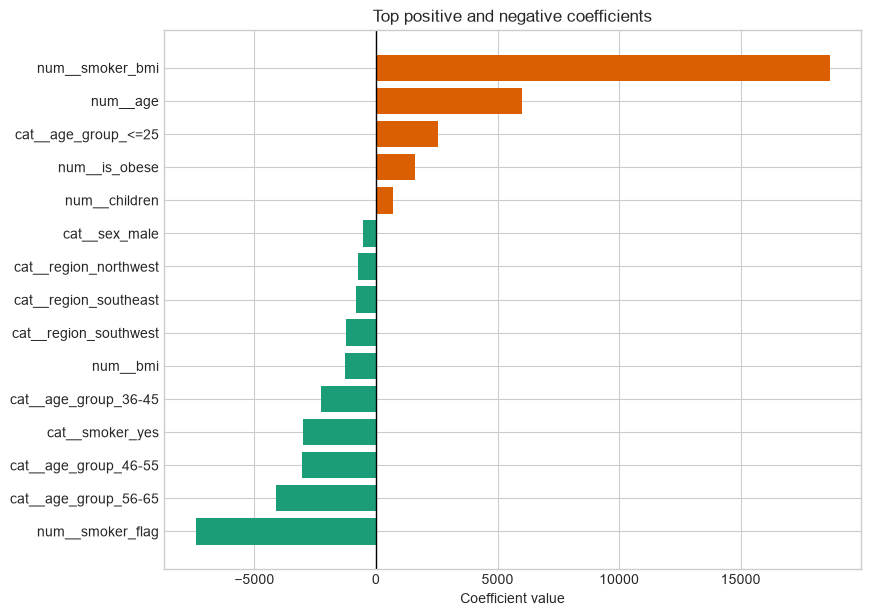

Top positive coefficients


,feature,coefficient
5,num__smoker_bmi,18661.995075
0,num__age,6015.073093
14,cat__age_group_<=25,2551.167706
3,num__is_obese,1625.317190
2,num__children,688.195035
6,cat__sex_male,-546.209799
8,cat__region_northwest,-724.375286
9,cat__region_southeast,-808.523990


Top negative coefficients


,feature,coefficient
4,num__smoker_flag,-7420.964745
13,cat__age_group_56-65,-4098.371019
12,cat__age_group_46-55,-3060.455342
7,cat__smoker_yes,-2999.144522
11,cat__age_group_36-45,-2281.488144
1,num__bmi,-1261.172630
10,cat__region_southwest,-1241.912072
9,cat__region_southeast,-808.523990


In [25]:
top_positive = coef_df.sort_values("coefficient", ascending=False).head(8)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(8)
plot_df = pd.concat([top_negative, top_positive]).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 7))
colors = np.where(plot_df["coefficient"] >= 0, "#d95f02", "#1b9e77")
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top positive and negative coefficients")
ax.set_xlabel("Coefficient value")
plt.show()

print("Top positive coefficients")
display(top_positive[["feature", "coefficient"]])

print("Top negative coefficients")
display(top_negative[["feature", "coefficient"]])


### Coefficient answers

1. Smoker-related features, especially the smoker-BMI interaction, increase predicted charges the most. Age also increases predicted charges.
2. Some region/age-group encoded coefficients may be negative depending on the reference category. Negative coefficients mean lower predicted charges compared with the omitted reference group, after controlling for other features.
3. Smoking has a very strong impact. Because `smoker`, `smoker_flag`, and `smoker_bmi` are related, the smoking effect is spread across multiple coefficients.
4. The signs are mostly reasonable, but coefficient interpretation should be cautious because engineered features create multicollinearity. Prediction can still be good even when individual coefficients are unstable.


## 10. Multicollinearity check

Check correlation among numerical features.

High feature-feature correlation can make coefficient interpretation unstable.

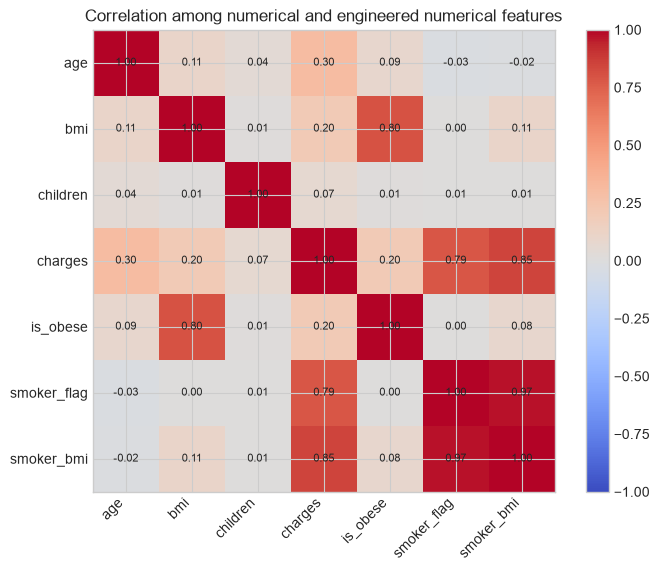

In [26]:
numeric_corr_fe = insurance_fe.select_dtypes(include=["int64", "float64"]).corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(numeric_corr_fe, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_corr_fe.columns)), labels=numeric_corr_fe.columns, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_corr_fe.columns)), labels=numeric_corr_fe.columns)
for i in range(len(numeric_corr_fe.columns)):
    for j in range(len(numeric_corr_fe.columns)):
        ax.text(j, i, f"{numeric_corr_fe.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation among numerical and engineered numerical features")
fig.colorbar(im, ax=ax)
plt.show()


In [27]:
corr_abs = numeric_corr_fe.abs()
high_corr_pairs = []

for i, col_1 in enumerate(corr_abs.columns):
    for col_2 in corr_abs.columns[i + 1:]:
        corr_value = corr_abs.loc[col_1, col_2]
        if corr_value >= 0.70:
            high_corr_pairs.append({
                "feature_1": col_1,
                "feature_2": col_2,
                "absolute_correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("absolute_correlation", ascending=False)
high_corr_df


,feature_1,feature_2,absolute_correlation
3,smoker_flag,smoker_bmi,0.974487
2,charges,smoker_bmi,0.845120
0,bmi,is_obese,0.799211
1,charges,smoker_flag,0.787251


### Multicollinearity answers

1. `smoker_flag` and `smoker_bmi` are highly correlated. `bmi` and `is_obese` are also highly correlated. This is expected because the engineered features were created from original columns.
2. Yes. High correlation can make coefficient interpretation unstable because the model may distribute importance across related features.
3. If the goal is best prediction, I may keep them and compare validation performance. If the goal is clean interpretation, I would remove duplicated features such as either `smoker_flag` or the categorical `smoker` encoding, and possibly choose between `bmi` and `is_obese`.


## 11. Compare with Ridge Regression

Ridge adds a penalty for large coefficients:

$$
\text{Ridge: } \min(MSE + \lambda\sum_j \beta_j^2)
$$

Train a Ridge model and compare it with Linear Regression.

In [28]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)
ridge_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'age_group','smoker_flag','smoker_bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

In [29]:
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

comparison = pd.DataFrame({
    "Linear Regression Train": regression_report(y_train, y_train_pred, n_features=n_transformed_features),
    "Linear Regression Test": regression_report(y_test, y_test_pred, n_features=n_transformed_features),
    "Ridge Train": regression_report(y_train, ridge_train_pred, n_features=n_transformed_features),
    "Ridge Test": regression_report(y_test, ridge_test_pred, n_features=n_transformed_features),
}).T

comparison.round(4)


,MAE,MSE,RMSE,R2,Adjusted R2
Linear Regression Train,2853.7222,2.244349e+07,4737.4560,0.8445,0.8423
Linear Regression Test,2760.9865,2.083316e+07,4564.3355,0.8658,0.8578
Ridge Train,2914.5265,2.330734e+07,4827.7678,0.8385,0.8362
Ridge Test,2847.2069,2.082323e+07,4563.2475,0.8659,0.8579


### Ridge answers

1. Ridge usually gives very similar test performance to Linear Regression on this dataset. Sometimes the RMSE/R2 changes only slightly.
2. Yes. Ridge reduces coefficient magnitudes because it penalizes large coefficients.
3. Regularization helps when features are correlated or when the model has many encoded/engineered features. It makes the model more stable and less sensitive to small changes in the training data.


## 12. Stretch goals

Try any two:

1. Compare with Lasso Regression.
2. Apply log transform to `charges` and compare performance.
3. Train separate models for smokers and non-smokers.
4. Add polynomial features for `age` or `bmi`.
5. Remove highly correlated features and retrain.

In [30]:
# Stretch 1: Lasso Regression
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=25.0, max_iter=10000))
])

lasso_model.fit(X_train, y_train)
lasso_test_pred = lasso_model.predict(X_test)

print("Lasso test performance")
display(regression_report(y_test, lasso_test_pred, n_features=n_transformed_features).round(4))

lasso_coef = lasso_model.named_steps["model"].coef_
print("Non-zero Lasso coefficients:", np.sum(lasso_coef != 0), "out of", len(lasso_coef))

# Stretch 2: Log-transform target
# This is useful because charges is heavily right-skewed.
y_train_log = np.log1p(y_train)

log_target_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
log_target_model.fit(X_train, y_train_log)
log_pred = np.expm1(log_target_model.predict(X_test))

print("Log-target Linear Regression test performance")
display(regression_report(y_test, log_pred, n_features=n_transformed_features).round(4))


Lasso test performance


MAE            2.753589e+03
MSE            2.053656e+07
RMSE           4.531728e+03
R2             8.677000e-01
Adjusted R2    8.598000e-01
dtype: float64

Non-zero Lasso coefficients: 13 out of 15
Log-target Linear Regression test performance


MAE            4.037448e+03
MSE            7.170766e+07
RMSE           8.468037e+03
R2             5.381000e-01
Adjusted R2    5.106000e-01
dtype: float64

## Final written summary

- Insurance charges are strongly right-skewed: most customers have moderate charges, while a smaller group has very high charges.
- Smoking is the most important driver of high medical charges in this dataset.
- Age has the strongest correlation with charges among the original numerical features; BMI also matters, especially for smokers.
- The `smoker_bmi` interaction is useful because the effect of BMI is different for smokers and non-smokers.
- Linear Regression performs well overall, with test R2 usually around 0.86 after feature engineering.
- The model still makes larger mistakes for very high-charge customers, showing that the relationship is not perfectly linear.
- Ridge Regression gives similar performance but shrinks coefficients, which is useful when features are correlated.
- To improve the model further, I would try log-transforming `charges`, adding non-linear features, and comparing Ridge/Lasso with cross-validation.
